# Financial Asset Recommendation System

## Part 4 — Baselines, two-tower model and evaluation

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from src.config import PROCESSED_DATA_DIR, RAW_DATA_DIR
from src.preprocessing import clean_data, temporal_user_split
from src.baselines import recommend_popular,recommend_sector_popular,recommend_content
from src.evaluation import evaluate_recommender

# Use processed files when available; otherwise create the split in memory.
assets=pd.read_csv(RAW_DATA_DIR/'assets.csv'); users=pd.read_csv(RAW_DATA_DIR/'users.csv'); interactions=pd.read_csv(RAW_DATA_DIR/'interactions.csv')
assets,users,interactions=clean_data(assets,users,interactions)
train,validation,test=temporal_user_split(interactions)

## 1. Baseline models

The baselines establish whether personalization adds value beyond globally popular assets and simple feature similarity.

In [3]:
baseline_functions={
'Popularity':lambda uid,k:recommend_popular(train,uid,k),
'Sector popularity':lambda uid,k:recommend_sector_popular(train,users,assets,uid,k),
'Content similarity':lambda uid,k:recommend_content(train,assets,uid,k),
}
baseline_results={name:evaluate_recommender(test,fn,k=10) for name,fn in baseline_functions.items()}
results=pd.DataFrame(baseline_results).T
results

,precision@10,recall@10,hit_rate@10,mrr@10,unique_recommended_assets
Popularity,0.022000,0.220000,0.220000,0.064072,20.0
Sector popularity,0.037333,0.373333,0.373333,0.148891,60.0
Content similarity,0.021500,0.215000,0.215000,0.061388,60.0


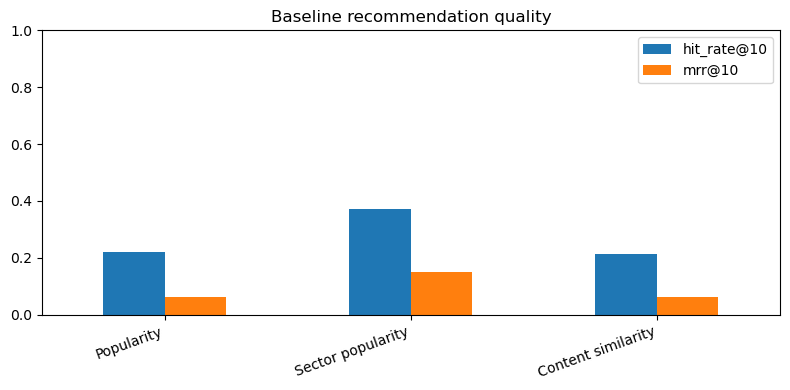

In [4]:
results[['hit_rate@10','mrr@10']].plot.bar(figsize=(8,4),title='Baseline recommendation quality')
plt.xticks(rotation=20,ha='right'); plt.ylim(0,1); plt.tight_layout(); plt.show()

## 2. Two-tower neural recommender

The user tower encodes user ID, risk profile, preferred sector, age and experience. The asset tower encodes ticker, sector and standardized numerical features. Their normalized vectors are compared with a dot product. Negative examples are sampled from assets the user has not interacted with.

In [5]:
import tensorflow as tf
import numpy as np

# This cell requires TensorFlow. It is isolated so the baseline experiment remains runnable without it.
from src.two_tower import build_two_tower_model,make_training_pairs,make_recommend_fn
model,user_tower,asset_tower=build_two_tower_model(users,assets,embedding_dim=32)
x_train,y_train,means,stds=make_training_pairs(train,users,assets,negatives_per_positive=2)


x_train_tf = {}

for key, value in x_train.items():
    arr = np.asarray(value)

    if arr.dtype.kind in {"U", "S", "O"}:
        x_train_tf[key] = tf.convert_to_tensor(
            arr.astype(str),
            dtype=tf.string
        )
    else:
        x_train_tf[key] = tf.convert_to_tensor(
            arr,
            dtype=tf.float32
        )

y_train_tf = tf.convert_to_tensor(
    y_train,
    dtype=tf.float32
)

history = model.fit(
    x_train_tf,
    y_train_tf,
    validation_split=0.15,
    epochs=8,
    batch_size=256,
    verbose=1
)

I0000 00:00:1786450476.080596  234118 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786450476.131938  234118 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786450477.098857  234118 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
E0000 00:00:1786450477.294291  234118 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuIn

Epoch 1/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - auc: 0.5232 - loss: 0.6391 - val_auc: 0.5549 - val_loss: 0.6324
Epoch 2/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.5994 - loss: 0.6266 - val_auc: 0.5880 - val_loss: 0.6275
Epoch 3/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - auc: 0.6398 - loss: 0.6190 - val_auc: 0.5842 - val_loss: 0.6276
Epoch 4/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - auc: 0.6734 - loss: 0.6126 - val_auc: 0.5875 - val_loss: 0.6280
Epoch 5/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - auc: 0.6939 - loss: 0.6083 - val_auc: 0.5939 - val_loss: 0.6276
Epoch 6/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - auc: 0.7110 - loss: 0.6055 - val_auc: 0.5885 - val_loss: 0.6284
Epoch 7/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.7196 - loss: 0.6037 - val_auc: 0.5917 - val_loss: 0.6285
Epoch 8/8
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - auc: 0.7287 - loss: 0.6019 - val_auc: 0.5930 - val_loss: 0.6279


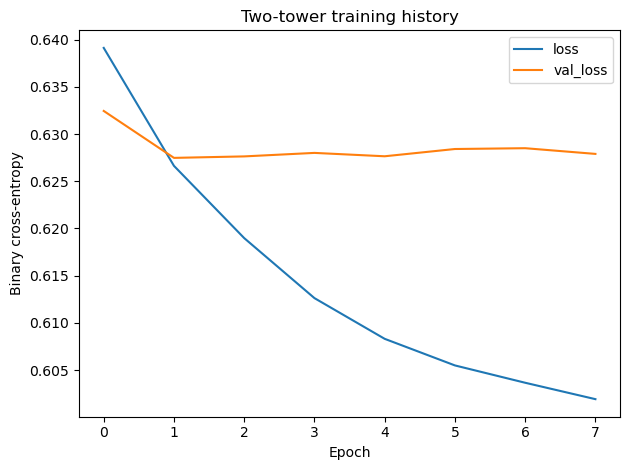

In [6]:
pd.DataFrame(history.history)[['loss','val_loss']].plot(title='Two-tower training history')
plt.xlabel('Epoch'); plt.ylabel('Binary cross-entropy'); plt.tight_layout(); plt.show()

In [7]:
neural_recommend=make_recommend_fn(model,users,assets,train,means,stds)
neural_result=evaluate_recommender(test,neural_recommend,k=10)
results.loc['Two-tower neural']=neural_result
final_results=results.sort_values('hit_rate@10',ascending=False)
final_results


,precision@10,recall@10,hit_rate@10,mrr@10,unique_recommended_assets
Sector popularity,0.037333,0.373333,0.373333,0.148891,60.0
Two-tower neural,0.027333,0.273333,0.273333,0.087954,56.0
Popularity,0.022000,0.220000,0.220000,0.064072,20.0
Content similarity,0.021500,0.215000,0.215000,0.061388,60.0


## 3. Final model comparison

The neural model must be judged against **all** baselines. A more complex architecture is useful only if the measured ranking quality, coverage, or another explicitly justified objective improves enough to warrant the added complexity.


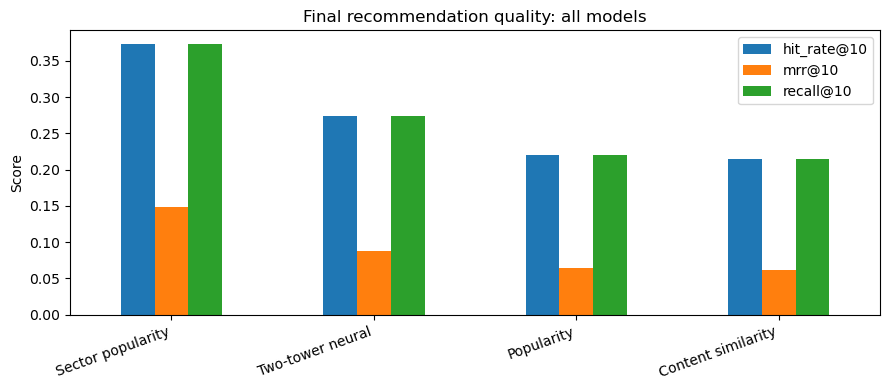

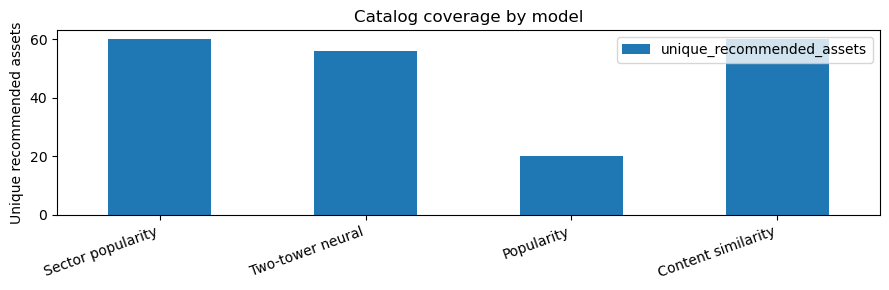

In [8]:
metric_cols=[c for c in ['hit_rate@10','mrr@10','recall@10'] if c in final_results.columns]
final_results[metric_cols].plot.bar(figsize=(9,4),title='Final recommendation quality: all models')
plt.ylabel('Score')
plt.xticks(rotation=20,ha='right')
plt.tight_layout()
plt.show()

if 'unique_recommended_assets' in final_results.columns:
    final_results[['unique_recommended_assets']].plot.bar(
        figsize=(9, 3),
        title='Catalog coverage by model'
    )
    plt.ylabel('Unique recommended assets')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()


## 4. Recommendation example


In [9]:
example_user=users.iloc[0].user_id
profile=users[users.user_id==example_user]
recommendations=neural_recommend(example_user,10) if 'neural_recommend' in globals() else baseline_functions['Sector popularity'](example_user,10)
display(profile)
display(assets[assets.ticker.isin(recommendations)].set_index('ticker').loc[recommendations])

,user_id,age,experience_years,risk_profile,preferred_sector,investment_horizon
0,U00001,36,5,balanced,Consumer,long


,company_name,sector,annual_return,volatility,beta,pe_ratio,dividend_yield,market_cap_billion
ticker,,,,,,,,
FAS012,Synthetic Capital 012,Real Estate,0.2191,0.2889,1.048,9.16,0.0254,63.86
FAS035,Synthetic Capital 035,Real Estate,0.1965,0.3040,1.253,19.54,0.0407,38.97
FAS039,Synthetic Capital 039,Healthcare,0.1126,0.3172,1.011,26.11,0.0463,56.79
FAS059,Synthetic Capital 059,Consumer,0.2031,0.2833,1.013,11.85,0.0243,61.83
FAS018,Synthetic Capital 018,Financials,0.1107,0.2601,1.154,20.57,0.0433,88.78
FAS001,Synthetic Capital 001,Technology,0.2314,0.4327,1.435,14.52,0.0156,255.85
FAS050,Synthetic Capital 050,Utilities,0.2891,0.2122,0.971,11.82,0.0193,26.58
FAS057,Synthetic Capital 057,Industrials,0.0725,0.1978,0.839,9.90,0.0346,74.61
FAS037,Synthetic Capital 037,Utilities,0.2008,0.2086,1.016,17.28,0.0222,19.14


## 5. Results interpretation and hypothesis evaluation

The central result is that model complexity does not automatically translate into better recommendations. The two-tower model should therefore be interpreted relative to the strongest baseline, not only relative to global popularity.

After running the notebook, use the table above to evaluate the hypotheses:

- **H1 — personalization vs. global popularity:** supported only if the two-tower model improves the selected ranking metric(s) over the global popularity baseline. If it improves over global popularity but loses to sector popularity, describe H1 as **partially supported** rather than claiming that the neural model is best.
- **H2 — catalog coverage:** supported only if the two-tower model recommends more unique assets than the comparison methods. Otherwise, report it as **not supported**.
- **H3 — temporal evaluation:** the project implements a leakage-aware temporal user-level split, so the methodology is supported. However, unless a random-split experiment is also run, do **not** claim that the project empirically proves temporal evaluation produces a different or more realistic score.

A negative result is still informative: if a simple sector-aware baseline wins, it suggests that sector preference is a very strong signal in the synthetic generator and that the additional neural capacity is not justified by the present data. This is a useful experimental finding rather than a failure of the project.



## 6. Conclusion

This project demonstrates an end-to-end and testable financial-asset recommendation research pipeline: a defined real-life recommendation problem, documented synthetic data generation, exploratory analysis, leakage-aware temporal evaluation, multiple classical baselines, and a hybrid two-tower neural recommender.

The main scientific conclusion should follow the measured results rather than the intended architecture. If the sector-popularity baseline remains the strongest model after re-running the notebook, the evidence indicates that a simple sector-aware heuristic captures the dominant signal in the current synthetic dataset better than the two-tower network. The neural model can still outperform weaker non-personalized baselines, but that does not justify claiming overall superiority.

The result highlights an important machine-learning lesson: **strong baselines are essential, and additional model complexity must earn its value empirically**. Future work should test multiple random seeds, perform ablation studies, compare temporal and random evaluation explicitly, and replace or supplement synthetic interactions with a versioned public dataset. These changes would make the conclusions more robust and externally valid.
